In [19]:
import grewpy
from grewpy import Corpus, CorpusDraft, Request
from collections import Counter
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting
import tod.dimension_reduction_classic

# treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_French-GSD"
treebank_path = "/Users/madalina/Downloads/bUD_English-GUM"
grew_pattern = "pattern{X[upos<>PUNCT]}"
patterns_text_file = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes.txt"
analysed_category = "all_nodes"

corpus = tod.corpus.Corpus(
    treebank_path=treebank_path,
    grew_pattern=grew_pattern,
    patterns_text_file=patterns_text_file,
    use_sud=False,
    matrix_type="coverage",
    # excluded_feature_patterns=[r"CxnElt=", r"Cxn=", r"own", r"Gender"]
        excluded_feature_patterns=[r"CxnElt=", r"Cxn=", r"XML=", r"PDTB=", r"SplitAnte=", r"MSeg=", r"Entity=", r"Discourse=", r"Bridge=", r"own", r"Degree=Pos"]
)

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(corpus.feature_matrix)

In [26]:
import numpy as np
results = []
lex_units_with_different_neighbours = set()
for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        if neighbour_category != current_category and similarity_matrix[idx][neighbour_idx] > 0.5:
            diff = np.abs(corpus.feature_matrix[idx] - corpus.feature_matrix[neighbour_idx])
            closest_features_idx= np.argsort(diff)[:-6:-1]
            closest_features = [corpus._idx2feature[i] for i in closest_features_idx]
                
            results.append({
                "lex_unit": lex_unit,
                "neighbour_lex_unit": corpus._idx2lexunit[neighbour_idx],
                "distance": similarity_matrix[idx][neighbour_idx],
                "closest_features": closest_features,
                
            })
            lex_units_with_different_neighbours.add(lex_unit)
    

for r in results:
    print(r)   

{'lex_unit': ('$', 'SYM'), 'neighbour_lex_unit': ('Factor', 'PROPN'), 'distance': 0.8279907818128358, 'closest_features': ['node:X:child:rel_shallow=nummod', 'node:X:child:rel_shallow=flat', 'node:X:prev:upos=ADP', 'node:X:parent:Number=Sing', 'node:X:child:rel_shallow=punct']}
{'lex_unit': ('$', 'SYM'), 'neighbour_lex_unit': ('Q', 'PROPN'), 'distance': 0.782434503177179, 'closest_features': ['node:X:child:rel_shallow=flat', 'node:X:child:rel_shallow=nummod', 'node:X:parent:Number=Sing', 'node:X:child:upos=PUNCT', 'node:X:child:rel_shallow=punct']}
{'lex_unit': ('$', 'SYM'), 'neighbour_lex_unit': ('Wave', 'PROPN'), 'distance': 0.7689568994602162, 'closest_features': ['node:X:child:rel_shallow=flat', 'node:X:child:rel_shallow=nummod', 'node:X:parent:upos=NOUN', 'node:X:parent:position=after', 'node:X:parent:Number=Sing']}
{'lex_unit': ('$', 'SYM'), 'neighbour_lex_unit': ('Figure', 'PROPN'), 'distance': 0.7291987385247293, 'closest_features': ['node:X:child:rel_shallow=flat', 'node:X:chi

In [22]:
len(lex_units_with_different_neighbours)

830

In [23]:
category_counts = {}
for idx, lex_unit in corpus._idx2lexunit.items():
    category = lex_unit[1]
    if category not in category_counts:
        category_counts[category] = {"total": 0, "with_different_neighbour": 0}
    category_counts[category]["total"] += 1
    if lex_unit in lex_units_with_different_neighbours:
        category_counts[category]["with_different_neighbour"] += 1

for category, counts in category_counts.items():
    total = counts["total"]
    with_diff = counts["with_different_neighbour"]
    percentage = (with_diff / total) * 100 if total > 0 else 0
    print(f"Category: {category}, Total: {total}, With Different Neighbour: {with_diff}, Percentage: {percentage:.2f}%")

Category: SYM, Total: 4, With Different Neighbour: 4, Percentage: 100.00%
Category: CCONJ, Total: 8, With Different Neighbour: 8, Percentage: 100.00%
Category: PART, Total: 3, With Different Neighbour: 3, Percentage: 100.00%
Category: ADP, Total: 52, With Different Neighbour: 18, Percentage: 34.62%
Category: NUM, Total: 70, With Different Neighbour: 31, Percentage: 44.29%
Category: NOUN, Total: 856, With Different Neighbour: 188, Percentage: 21.96%
Category: PROPN, Total: 214, With Different Neighbour: 191, Percentage: 89.25%
Category: ADJ, Total: 286, With Different Neighbour: 120, Percentage: 41.96%
Category: PRON, Total: 38, With Different Neighbour: 38, Percentage: 100.00%
Category: VERB, Total: 375, With Different Neighbour: 21, Percentage: 5.60%
Category: DET, Total: 17, With Different Neighbour: 17, Percentage: 100.00%
Category: ADV, Total: 141, With Different Neighbour: 117, Percentage: 82.98%
Category: SCONJ, Total: 29, With Different Neighbour: 29, Percentage: 100.00%
Categor

In [51]:
from scipy.stats import entropy
scores = {}
for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    purity_top, purity_bottom = 0, 0
    category_weights = {}
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        distance_to_neighbour = similarity_matrix[idx][neighbour_idx]
        purity_bottom += distance_to_neighbour # the sum of all the inverse weights
        if neighbour_category in category_weights:
            category_weights[neighbour_category] += distance_to_neighbour
        else:
            category_weights[neighbour_category] = distance_to_neighbour

        if neighbour_category == current_category:
            purity_top += distance_to_neighbour

    purity_score = purity_top / purity_bottom

    probabilities = [v / purity_bottom for v in category_weights.values()]
    entropy_score = entropy(probabilities)
    
    scores[lex_unit] = {}
    scores[lex_unit]["purity"] = purity_score
    scores[lex_unit]["entropy"] = entropy_score

    rival_cat = None
    rival_weight = 0

    for cat, w in category_weights.items():
        if cat != current_category and w > rival_weight:
            rival_weight = w
            rival_cat = cat

    scores[lex_unit]["rival_category"] = rival_cat
    scores[lex_unit]["rival_weight_ratio"] = rival_weight / purity_bottom if purity_bottom > 0 else 0
    

In [64]:
scores

{('$', 'SYM'): {'purity': 0.0,
  'entropy': 0.7853897358164348,
  'rival_category': 'PROPN',
  'rival_weight_ratio': 0.6522623519525523},
 ('%', 'SYM'): {'purity': 0.03883846645303713,
  'entropy': 0.6469523789467088,
  'rival_category': 'NOUN',
  'rival_weight_ratio': 0.820150583273663},
 ('&', 'CCONJ'): {'purity': 0.0,
  'entropy': 1.0118200569187281,
  'rival_category': 'PROPN',
  'rival_weight_ratio': 0.6302466199441362},
 ("'s", 'PART'): {'purity': 0.0,
  'entropy': 1.2695434228012887,
  'rival_category': 'PROPN',
  'rival_weight_ratio': 0.6435687753624298},
 ('+', 'SYM'): {'purity': 0.05362047941118794,
  'entropy': 1.3905968127783355,
  'rival_category': 'ADP',
  'rival_weight_ratio': 0.578772308059643},
 ('-', 'ADP'): {'purity': 0.0,
  'entropy': 1.1532560630335542,
  'rival_category': 'PROPN',
  'rival_weight_ratio': 0.6028117461446422},
 ('/', 'SYM'): {'purity': 0.0,
  'entropy': 1.0093634394193707,
  'rival_category': 'ADP',
  'rival_weight_ratio': 0.6858622389610515},
 ('0'

In [60]:
import plotly.express as px
import pandas as pd

# Convert your 'scores' dictionary to a DataFrame
df = pd.DataFrame.from_dict(scores, orient='index')

# # Assuming lex_unit was a tuple (word, pos)
# df['word'] = df.index.apply(lambda x: x[0])
# df['category'] = df['index'].apply(lambda x: x[1])

# # Calculate medians for the dashed lines
med_p = df['purity'].median()
med_e = df['entropy'].median()

fig = px.scatter(
    df, x="purity", y="entropy",  
    hover_name=list(df.index),
    hover_data={
        "purity": True,
        "entropy": True,
        "rival_category": True,
        "rival_weight_ratio": True
    },
    title="Polycategoriality Analysis: Purity vs Entropy",
    labels={"purity": "Purity (Categorical Homogeneity)", "entropy": "Entropy (Categorical Competition)", "rival_category": "Other category around", "rival_weight_ratio": "Its weight"},
    # template="plotly_dark" # Or "plotly_white"
)

# Add the "Crosshair" at the medians

fig.add_vline(x=med_p, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_hline(y=med_e, line_dash="dash", line_color="gray", opacity=0.5)

fig.show()

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify the 'Rival' for each unit
matrix_data = []

for lex_unit, stats in scores.items():
    current_cat = lex_unit[1]
    
    # We only care about units that have some level of 'pull' from others
    if stats['rival_category'] is not None:
        
       matrix_data.append(
           {
               "Original": current_cat,
               "Rival": stats['rival_category']
           }
       )
df_transitions = pd.DataFrame(matrix_data)
transition_matrix = pd.crosstab(
    df_transitions['Original'], 
    df_transitions['Rival'], 
    normalize='index'
)


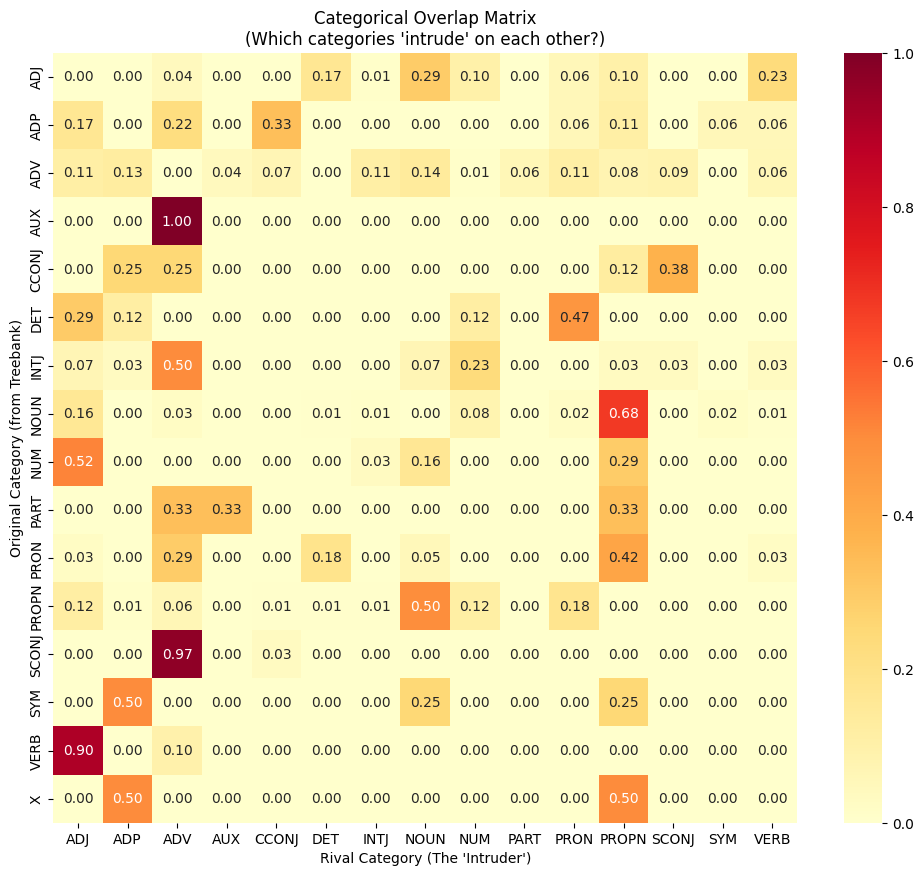

In [63]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    transition_matrix, 
    annot=True,      # Show the numbers in the cells
    cmap="YlOrRd",   # Color gradient: Yellow (low) to Red (high)
    fmt=".2f"        # Format to 2 decimal places
)

plt.title("Categorical Overlap Matrix\n(Which categories 'intrude' on each other?)")
plt.ylabel("Original Category (from Treebank)")
plt.xlabel("Rival Category (The 'Intruder')")
plt.show()

In [120]:
def get_top_bridge_words(scores_dict, original_cat, rival_cat, top_n=100):
    """Finds the words from original_cat most pulled toward rival_cat."""
    matches = []
    
    for (word, o_cat), data in scores_dict.items():
        if o_cat == original_cat and data["rival_category"] == rival_cat:
            matches.append((word, data["purity"], data["entropy"]))
            
    # Sort by lowest purity (the ones most 'pulled' away)
    matches.sort(key=lambda x: x[1])
    
    return matches[:top_n]

# Example: Who are the Verbs that look like Adjectives?
category_to_compare_1 = "ADJ"
category_to_compare_2 = "NOUN"
bridge_verbs = get_top_bridge_words(scores, category_to_compare_1, category_to_compare_2)
print(f"Top {category_to_compare_1} -> {category_to_compare_2} bridge words: ")
print(f"Word \t Purity \t Entropy")
for v in bridge_verbs:
    print(v)

Top ADJ -> NOUN bridge words: 
Word 	 Purity 	 Entropy
('tall', 0.05207681837472146, 1.1619560529525628)
('like', 0.5771472586853559, 0.9617629516415034)
('residential', 0.6792694549490308, 0.6274188960017739)
('non-avian', 0.7926356318086879, 0.6541767661552758)
('own', 0.8038520957224848, 0.4950156885681527)
('blue', 0.8418973326996718, 0.43651023354827884)
('Black', 0.8941566388273643, 0.4110957245214434)
('arrogant', 0.894237302433035, 0.41085849574024164)
('same', 0.8945809844002099, 0.3368291744805927)
('other', 0.8949403880803605, 0.4088779750499426)
('native', 0.8962671320047096, 0.33320835026115436)
('few', 0.8965445563004711, 0.40431657426411094)
('favorite', 0.9010277735456307, 0.3914186124284098)
('moral', 0.9462823632317182, 0.20931940955753525)
('legal', 0.9465250370189472, 0.20862264699659977)
('eastern', 0.946919500299706, 0.20748758300597972)
('only', 0.9469251594298252, 0.20747127644461533)
('classical', 0.9469670846807912, 0.20735045062741295)
('whole', 0.94713112511

In [ ]:
def get_pulling_features(lex_unit, rival_category, corpus, similarity_matrix, top_k_features=20):
    lex_unit_vector = corpus.feature_matrix[corpus._lexunit2idx[lex_unit]]
    closest_neighbours_indices = np.argsort(similarity_matrix[idx])[::-1]
    rival_cat_neighbours_idx = []
    for i in closest_neighbours_indices:
        if i != corpus._lexunit2idx[lex_unit] and corpus._idx2lexunit[i][1] == rival_category:
            rival_cat_neighbours_idx.append(i)
    
    rival_centroid = np.median(corpus.feature_matrix[rival_cat_neighbours_idx[:20]], axis=0)
    
    feat_idx_to_compare = []
    for feature_value_idx in range(len(rival_centroid)):
        if rival_centroid[feature_value_idx] > 0:
            feat_idx_to_compare.append(feature_value_idx)

    diffs = {}
    for f in feat_idx_to_compare:
        diff = abs(lex_unit_vector[f] - rival_centroid[f])
        diffs[f] = diff

    for f_idx, diff in diffs.items():
        print(corpus.idx2feature(idx), diff)
    # feature_differences = np.abs(lex_unit_vector - rival_centroid)
    
    # global_variance = np.var(corpus.feature_matrix, axis=0)

    # bridge_score = global_variance / (feature_differences + 1e-6)
    # top_feature_indices = np.argsort(bridge_score)[::-1][:top_k_features]

    # most_similar_features = {}
    # for i in range(len(feature_differences)):
    #     if feature_differences[i] > 0:
    #         most_similar_features[corpus._idx2feature[i]] = feature_differences[i]
    
    # sorted_most_similar_features = {k: v for k, v in sorted(most_similar_features.items(), key = lambda item: item[1])}
    # print(sorted_most_similar_features)
    # # We rank by (Value / (Difference + epsilon)) 
    # # This prioritizes high-frequency features that match the rival perfectly
    # relevance_score = lex_unit_vector / (feature_differences + 1e-6)
    # top_feature_indices = np.argsort(relevance_score)[::-1][:top_k_features]
    # results = []
    # for f_idx in top_feature_indices:
    #     print(corpus._idx2feature[f_idx])
    #     # results.append(
    #     #     {
    #     #     "feature": corpus._idx2feature[f_idx],
    #     #     "unit_value": lex_unit_vector[f_idx],
    #     #     "rival_avg": rival_centroid[f_idx],
    #     #     "diff": feature_differences[f_idx]
    #     #     }
    #     # )


In [119]:
get_pulling_features(('willing', 'ADJ'), "VERB", corpus, similarity_matrix)

UnboundLocalError: cannot access local variable 'idx' where it is not associated with a value

In [94]:
result = get_pulling_features(('willing', 'ADJ'), "VERB", corpus, similarity_matrix)
print(result)

None
